In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 29.1 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
from catboost import CatBoost, Pool

In [4]:
import os
os.listdir('/content/drive/MyDrive/Colab Notebooks/')

['catboost.ipynb',
 'train.parquet',
 'test.parquet',
 'train_fe.parquet',
 'val_fe.parquet',
 'test_fe.parquet',
 'prepare.ipynb']

In [5]:
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks"

df_train = pd.read_parquet(f"{DATA_DIR}/train_fe.parquet")
df_val   = pd.read_parquet(f"{DATA_DIR}/val_fe.parquet")
df_test  = pd.read_parquet(f"{DATA_DIR}/test_fe.parquet")

print(f"train: {df_train.shape}, val: {df_val.shape}, test: {df_test.shape}")

train: (4215569, 65), val: (742778, 65), test: (4959183, 61)


In [6]:
df_train = df_train.sort_values('srch_id').reset_index(drop=True)
df_val   = df_val.sort_values('srch_id').reset_index(drop=True)
df_test  = df_test.sort_values('srch_id').reset_index(drop=True)

In [7]:
exclude_cols = ['srch_id', 'prop_id', 'relevance', 'date_time',
                'click_bool', 'booking_bool', 'gross_bookings_usd']
features = [c for c in df_train.columns if c not in exclude_cols]

X_train, y_train = df_train[features].copy(), df_train['relevance']
X_val,   y_val   = df_val[features].copy(),   df_val['relevance']
X_test           = df_test[features].copy()

cat_features = ['site_id', 'prop_country_id', 'srch_destination_id']
cat_features = [c for c in cat_features if c in features]
for c in cat_features:
    for df in [X_train, X_val, X_test]:
        df[c] = df[c].fillna(-1).astype(int).astype(str)

print(f"Features: {len(features)}, categorical: {cat_features}")
print(f"position in features: {'position' in features}  (train/val use real, test filled with train mean)")

Features: 58, categorical: ['site_id', 'prop_country_id', 'srch_destination_id']
position in features: True  (train/val use real, test filled with train mean)


In [8]:
train_pool = Pool(
    data=X_train,
    label=y_train,
    group_id=df_train['srch_id'],
    cat_features=cat_features,
)
val_pool = Pool(
    data=X_val,
    label=y_val,
    group_id=df_val['srch_id'],
    cat_features=cat_features,
)
test_pool = Pool(
    data=X_test,
    cat_features=cat_features,
)

In [15]:
param_grid = [
    {'depth': 8,  'learning_rate': 0.05, 'l2_leaf_reg': 3, 'random_strength': 1},
    {'depth': 10, 'learning_rate': 0.05, 'l2_leaf_reg': 3, 'random_strength': 1},
    {'depth': 10, 'learning_rate': 0.03, 'l2_leaf_reg': 5, 'random_strength': 1},
    {'depth': 8,  'learning_rate': 0.05, 'l2_leaf_reg': 3, 'random_strength': 1,
     'bootstrap_type': 'Bernoulli', 'subsample': 0.8},
]

base_params = {
    'loss_function':  'YetiRank',
    'eval_metric':    'NDCG:top=5;type=Exp',
    'custom_metric':  ['NDCG:top=5;type=Exp'],
    'iterations':     5000,
    'random_seed':    42,
    'task_type':      'GPU',
    'verbose':        100,
    'use_best_model': True,
    'od_type':        'Iter',
    'od_wait':        200,
}


def extract_best_ndcg(model):
    """Pull the type=Exp NDCG specifically. CatBoost auto-tracks the default
    type=Base (linear gain) alongside our custom Exp metric, and Base scores
    higher than Exp on this data — grabbing the wrong one inflates the result.
    """
    er = model.get_evals_result()
    candidates = []
    for split, metrics in er.items():
        if split == 'learn':
            continue
        for metric_name, history in metrics.items():
            if 'NDCG' in metric_name:
                candidates.append((metric_name, max(history)))
    for name, val in candidates:
        if 'Exp' in name:
            return val
    return candidates[0][1] if candidates else float('nan')


best_params = None
best_ndcg   = -np.inf

for i, hp in enumerate(param_grid):
    params = {**base_params, **hp}
    print(f"\n[{i+1}/{len(param_grid)}] Testing: {hp}")

    model = CatBoost(params)
    model.fit(train_pool, eval_set=val_pool)

    score = extract_best_ndcg(model)
    print(f"  NDCG@5 (Exp) = {score:.4f}  best_iter={model.best_iteration_}")

    if score > best_ndcg:
        best_ndcg   = score
        best_params = params
        best_model  = model

print(f"\nBest NDCG@5 (Exp) = {best_ndcg:.4f}")
print(f"Best params: {best_params}")


[1/4] Testing: {'depth': 8, 'learning_rate': 0.05, 'l2_leaf_reg': 3, 'random_strength': 1}
Groupwise loss function. OneHotMaxSize set to 10


Default metric period is 5 because NDCG is/are not implemented for GPU
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:top=5;type=Exp is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:top=5;type=Exp is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	test: 0.3441405	best: 0.3441405 (0)	total: 80.5ms	remaining: 6m 42s
100:	test: 0.3765416	best: 0.3765416 (100)	total: 7.44s	remaining: 6m
200:	test: 0.3842848	best: 0.3842848 (200)	total: 14.8s	remaining: 5m 52s
300:	test: 0.3884463	best: 0.3884549 (297)	total: 22s	remaining: 5m 43s
400:	test: 0.3915982	best: 0.3916026 (399)	total: 29.2s	remaining: 5m 35s
500:	test: 0.3934715	best: 0.3935485 (494)	total: 36.5s	remaining: 5m 27s
600:	test: 0.3949283	best: 0.3949627 (596)	total: 43.8s	remaining: 5m 20s
700:	test: 0.3963495	best: 0.3963495 (700)	total: 51s	remaining: 5m 12s
800:	test: 0.3972921	best: 0.3972984 (786)	total: 58.2s	remaining: 5m 5s
900:	test: 0.3984251	best: 0.3984361 (889)	total: 1m 5s	remaining: 4m 57s
1000:	test: 0.3996043	best: 0.3996232 (987)	total: 1m 12s	remaining: 4m 50s
1100:	test: 0.4005680	best: 0.4006176 (1098)	total: 1m 19s	remaining: 4m 42s
1200:	test: 0.4016531	best: 0.4017365 (1195)	total: 1m 26s	remaining: 4m 35s
1300:	test: 0.4026969	best: 0.4027318 (129

Default metric period is 5 because NDCG is/are not implemented for GPU
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:top=5;type=Exp is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:top=5;type=Exp is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	test: 0.3427702	best: 0.3427702 (0)	total: 96.7ms	remaining: 8m 3s
100:	test: 0.3795603	best: 0.3795603 (100)	total: 8.94s	remaining: 7m 13s
200:	test: 0.3858344	best: 0.3858578 (199)	total: 17.8s	remaining: 7m 4s
300:	test: 0.3894995	best: 0.3894995 (300)	total: 26.7s	remaining: 6m 56s
400:	test: 0.3924621	best: 0.3924700 (399)	total: 35.6s	remaining: 6m 47s
500:	test: 0.3941856	best: 0.3942418 (495)	total: 44.5s	remaining: 6m 39s
600:	test: 0.3960721	best: 0.3960721 (600)	total: 53.5s	remaining: 6m 31s
700:	test: 0.3982744	best: 0.3983028 (690)	total: 1m 2s	remaining: 6m 23s
800:	test: 0.3997346	best: 0.3997704 (799)	total: 1m 11s	remaining: 6m 14s
900:	test: 0.4009825	best: 0.4010071 (897)	total: 1m 20s	remaining: 6m 5s
1000:	test: 0.4020553	best: 0.4020553 (1000)	total: 1m 29s	remaining: 5m 57s
1100:	test: 0.4026872	best: 0.4026872 (1100)	total: 1m 38s	remaining: 5m 48s
1200:	test: 0.4032764	best: 0.4032973 (1197)	total: 1m 47s	remaining: 5m 39s
1300:	test: 0.4040869	best: 0.404

Default metric period is 5 because NDCG is/are not implemented for GPU
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:top=5;type=Exp is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:top=5;type=Exp is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	test: 0.3427629	best: 0.3427629 (0)	total: 95.8ms	remaining: 7m 58s
100:	test: 0.3759796	best: 0.3761060 (99)	total: 9.01s	remaining: 7m 17s
200:	test: 0.3811009	best: 0.3811009 (200)	total: 17.9s	remaining: 7m 6s
300:	test: 0.3847292	best: 0.3847922 (298)	total: 26.8s	remaining: 6m 58s
400:	test: 0.3872370	best: 0.3872370 (400)	total: 35.7s	remaining: 6m 49s
500:	test: 0.3897672	best: 0.3899457 (494)	total: 44.6s	remaining: 6m 40s
600:	test: 0.3916299	best: 0.3916299 (600)	total: 53.5s	remaining: 6m 31s
700:	test: 0.3933454	best: 0.3934510 (697)	total: 1m 2s	remaining: 6m 23s
800:	test: 0.3943579	best: 0.3943713 (797)	total: 1m 11s	remaining: 6m 14s
900:	test: 0.3951178	best: 0.3952057 (892)	total: 1m 20s	remaining: 6m 5s
1000:	test: 0.3961112	best: 0.3961112 (1000)	total: 1m 29s	remaining: 5m 57s
1100:	test: 0.3972202	best: 0.3972999 (1094)	total: 1m 38s	remaining: 5m 48s
1200:	test: 0.3987505	best: 0.3987813 (1198)	total: 1m 47s	remaining: 5m 39s
1300:	test: 0.3997371	best: 0.399

Default metric period is 5 because NDCG is/are not implemented for GPU
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:top=5;type=Exp is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:top=5;type=Exp is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	test: 0.3478090	best: 0.3478090 (0)	total: 80.8ms	remaining: 6m 43s
100:	test: 0.3763771	best: 0.3764619 (98)	total: 7.36s	remaining: 5m 56s
200:	test: 0.3841379	best: 0.3841379 (200)	total: 14.6s	remaining: 5m 49s
300:	test: 0.3884291	best: 0.3884879 (299)	total: 21.9s	remaining: 5m 41s
400:	test: 0.3915213	best: 0.3916271 (399)	total: 29.1s	remaining: 5m 33s
500:	test: 0.3935678	best: 0.3936442 (497)	total: 36.4s	remaining: 5m 26s
600:	test: 0.3949795	best: 0.3949795 (600)	total: 43.6s	remaining: 5m 19s
700:	test: 0.3958797	best: 0.3962040 (693)	total: 50.9s	remaining: 5m 12s
800:	test: 0.3973651	best: 0.3973651 (800)	total: 58.1s	remaining: 5m 4s
900:	test: 0.3985398	best: 0.3985398 (900)	total: 1m 5s	remaining: 4m 57s
1000:	test: 0.3999001	best: 0.3999728 (996)	total: 1m 12s	remaining: 4m 49s
1100:	test: 0.4009639	best: 0.4009942 (1099)	total: 1m 19s	remaining: 4m 42s
1200:	test: 0.4020039	best: 0.4020039 (1200)	total: 1m 27s	remaining: 4m 35s
1300:	test: 0.4025448	best: 0.40254

In [16]:
df_all = pd.concat([df_train, df_val], ignore_index=True).sort_values('srch_id').reset_index(drop=True)
X_all  = df_all[features].copy()
y_all  = df_all['relevance']
for c in cat_features:
    X_all[c] = X_all[c].fillna(-1).astype(int).astype(str)

all_pool = Pool(
    data=X_all,
    label=y_all,
    group_id=df_all['srch_id'],
    cat_features=cat_features,
)

final_params = {k: v for k, v in best_params.items()
                if k not in ('od_type', 'od_wait', 'use_best_model')}
final_params['iterations'] = int(best_model.best_iteration_ * 1.1)
print(f"Final iterations: {final_params['iterations']}  (best_iter * 1.1 to account for larger train+val)")
final_model = CatBoost(final_params)
final_model.fit(all_pool)
print("Final model trained.")

Final iterations: 3352  (best_iter * 1.1 to account for larger train+val)
Groupwise loss function. OneHotMaxSize set to 10


Default metric period is 5 because NDCG is/are not implemented for GPU
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:top=5;type=Exp is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:top=5;type=Exp is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	total: 97.4ms	remaining: 5m 26s
100:	total: 9.83s	remaining: 5m 16s
200:	total: 19.5s	remaining: 5m 5s
300:	total: 29.1s	remaining: 4m 55s
400:	total: 38.7s	remaining: 4m 45s
500:	total: 48.5s	remaining: 4m 35s
600:	total: 58.2s	remaining: 4m 26s
700:	total: 1m 8s	remaining: 4m 17s
800:	total: 1m 17s	remaining: 4m 7s
900:	total: 1m 27s	remaining: 3m 58s
1000:	total: 1m 37s	remaining: 3m 48s
1100:	total: 1m 47s	remaining: 3m 39s
1200:	total: 1m 57s	remaining: 3m 29s
1300:	total: 2m 6s	remaining: 3m 20s
1400:	total: 2m 16s	remaining: 3m 10s
1500:	total: 2m 26s	remaining: 3m
1600:	total: 2m 36s	remaining: 2m 51s
1700:	total: 2m 46s	remaining: 2m 41s
1800:	total: 2m 56s	remaining: 2m 31s
1900:	total: 3m 5s	remaining: 2m 21s
2000:	total: 3m 15s	remaining: 2m 12s
2100:	total: 3m 25s	remaining: 2m 2s
2200:	total: 3m 35s	remaining: 1m 52s
2300:	total: 3m 44s	remaining: 1m 42s
2400:	total: 3m 54s	remaining: 1m 32s
2500:	total: 4m 4s	remaining: 1m 23s
2600:	total: 4m 14s	remaining: 1m 13s
270

In [17]:
df_test['predicted_score'] = final_model.predict(test_pool)

submission = (
    df_test
    .sort_values(['srch_id', 'predicted_score'], ascending=[True, False])
    [['srch_id', 'prop_id']]
    .rename(columns={'srch_id': 'SearchId', 'prop_id': 'PropertyId'})
)

submission.to_csv(f"{DATA_DIR}/submission_catboost.csv", index=False)
print(f"Submission saved: {len(submission)} rows")
submission.head(10)

Submission saved: 4959183 rows


,SearchId,PropertyId
23,1,99484
9,1,54937
13,1,28181
3,1,50162
28,1,3180
12,1,34263
0,1,5543
14,1,74045
4,1,63894
27,1,90385


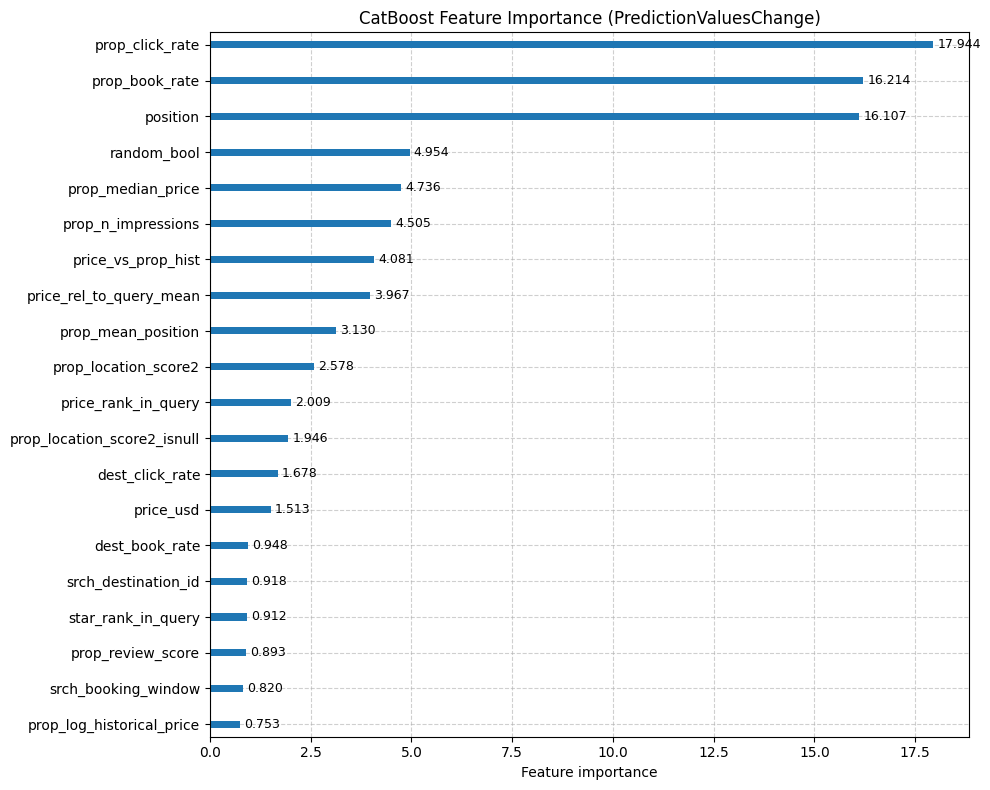

In [25]:
import matplotlib.pyplot as plt

importances = final_model.get_feature_importance(type='PredictionValuesChange')
imp = pd.Series(importances, index=features).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
imp.plot.barh(ax=ax, width=0.2)
ax.bar_label(ax.containers[0], fmt="%.3f", padding=3, fontsize=9)
ax.grid(axis="both", linestyle="--", alpha=0.6)
ax.set_axisbelow(True)
ax.set_xlabel("Feature importance")
ax.set_title("CatBoost Feature Importance (PredictionValuesChange)")
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/catboost_feature_importance.pdf")
plt.show()